In [16]:
import os
import win32com.client as win32
from y_n import y_n_distribution
from upsilon_n import upsilon_n
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
import pandas as pd
from sklearn.model_selection import ParameterSampler, ParameterGrid
import numpy as np

In [2]:
from models_FTS.components import parafins, olefins, others

In [3]:
hysys = win32.Dispatch("HYSYS.Application")

In [4]:
os.chdir("Z:\\uem\\Doutorado\\Ensaios\\SAF\\SAF_8_08_08_2025\\SAF_kinetics_paper_code")
path = "hysys_simulation_parametric_study"
hy_path = os.path.abspath(path)

In [5]:
hy_case = hysys.Application.ActiveDocument
if hy_case == None:
    hy_case = hysys=SimulationCase.Open(hy_path)

hy_case.Visible = 1

In [6]:
hy_solver = hy_case.Solver
hy_int = hy_solver.Integrator

hy_f = hy_case.Flowsheet

hy_package = hy_f.FluidPackage

In [7]:
hy_ms = hy_f.MaterialStreams
hy_es = hy_f.EnergyStreams

In [8]:
hy_case.Solver.CanSolve = False

In [9]:
reactor = hy_case.Flowsheet.Operations.Item('PFR-100')

In [10]:
reactor.TotalVolume.GetValue('mL')

7.880000000000001

In [11]:
n_parafins = {}
for i, parafin in enumerate(parafins):
    n = i + 1
    if n not in [4, 5, 6, 7, 8, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]:
        n_parafins[parafin] = n

n_olefins = {}
for i, olefin in enumerate(olefins):
    n = i + 2
    if n not in [3, 4, 5, 6, 7, 8]:
        n_olefins[olefin] = n

N = list(set(list(n_parafins.values()) + list(n_olefins.values())))

In [12]:
rxn_set = hy_case.BasisManager.ReactionPackageManager.ReactionSets.Item('FTS')

In [13]:
def solve_param_study(parametric_data):
    for i in parametric_data.index:
        T = parametric_data.T_K[i]
        P = parametric_data.P_Pa[i]
        F_in = parametric_data.F_in_mol_s[i]
        H2_CO = parametric_data.H2_CO[i]
        F_in_CO =  F_in / ( 1 + H2_CO )
        F_in_H2 =  H2_CO * F_in_CO
        
        y_in_H2 = F_in_H2 / F_in
        y_in_CO = F_in_CO / F_in
        
        F0 = hy_ms.Item('F0')
        P0 = hy_ms.Item('P0')
        
        F0_molar_frac = list(F0.ComponentMolarFractionValue)
        
        F0_molar_frac[F0.ComponentIndices('Hydrogen')[0]] = y_in_H2 
        F0_molar_frac[F0.ComponentIndices('CO')[0]] = y_in_CO
        
        F0.ComponentMolarFractionValue = F0_molar_frac
        
        F0.MolarFlow.SetValue(F_in, 'gmole/s')
        F0.Pressure.SetValue(P, 'Pa')
        F0.Temperature.SetValue(T, 'K')
        P0.Temperature.SetValue(T, 'K')
        
        y_n_dist = y_n_distribution(T, H2_CO, N)
    
        # must multiply reaction rate by correction factor below
        # because hysys bases reaction rate only on the gas phase, not the catalyst volume
        vol_cat_to_vol_gas =  (1 / reactor.VoidFraction) - 1 # m³ cat / m³ gas
        overall_freq_fact = 11153 # kmol / s / m³ cat / Pa²
        
        for component, n in n_parafins.items():
            freq_fact = n * y_n_dist[n] * upsilon_n(n) * overall_freq_fact * vol_cat_to_vol_gas # kmol / s / m³ gas / Pa²
            rxn_set.ReactionPackage.Reactions.Item(component).ForwardFrequencyFactor = freq_fact
        
        for component, n in n_olefins.items():
            freq_fact = n * y_n_dist[n] * ( 1 - upsilon_n(n) ) * overall_freq_fact * vol_cat_to_vol_gas # kmol / s / m³ / Pa²
            rxn_set.ReactionPackage.Reactions.Item(component).ForwardFrequencyFactor = freq_fact
        
        # solve
        # 3. Ligar o solver
        hy_case.Solver.CanSolve = True
        print(f'running simulation {i} of {parametric_data.index.max()}')
        clear_output(wait = True)
        
        # 4. Aguardar a convergência
        while hy_case.Solver.IsSolving:
            pass
        
        hy_case.Solver.CanSolve = False
        
        P0_molar_flow = list(P0.ComponentMolarFlowValue)
        F0_molar_flow = list(F0.ComponentMolarFlowValue)
        
        F_H2_out = P0_molar_flow[P0.ComponentIndices('Hydrogen')[0]]
        F_CO_out = P0_molar_flow[P0.ComponentIndices('CO')[0]]
        
        F_H2_in = F0_molar_flow[F0.ComponentIndices('Hydrogen')[0]]
        F_CO_in = F0_molar_flow[F0.ComponentIndices('CO')[0]]
        
        parametric_data.loc[i, 'X_CO'] = (F_CO_in - F_CO_out) / F_CO_in
        parametric_data.loc[i, 'X_H2'] = (F_H2_in - F_H2_out) / F_H2_in
        parametric_data.loc[i, 'F_H2_out'] = F_H2_out * 1000 # convert from kmol/s to mol/s
        parametric_data.loc[i, 'F_CO_out'] = F_CO_out * 1000

    return parametric_data

In [24]:
param_grid_T_H2_CO = {'T_K'      : np.linspace(210+273, 250+273, num = 15), 
              'P_Pa'     : [2e6],
              'H2_CO'    : np.linspace(1, 3, num = 3),
              'F_in_mol_s' : [0.00013599742941543852],
             }

parametric_data_T_H2_CO = pd.DataFrame(ParameterGrid(param_grid_T_H2_CO))
parametric_data_T_H2_CO = solve_param_study(parametric_data_T_H2_CO)
parametric_data_T_H2_CO.to_pickle('parametric_data/T_H2_CO.pkl')

running simulation 44 of 44


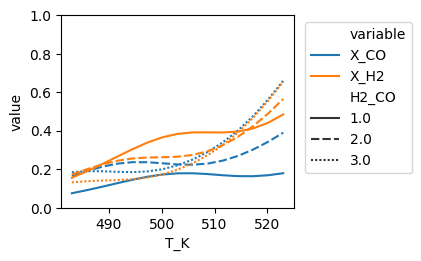

In [27]:
plot_T_vs_X = parametric_data_T_H2_CO[['X_CO', 'X_H2', 
                               'T_K', 'P_Pa', 
                               'H2_CO']].melt(id_vars = ['T_K', 'P_Pa', 'H2_CO'])

fig, axs = plt.subplots(figsize=(3,2.5))

sns.lineplot(
                data=plot_T_vs_X, 
                x='T_K', 
                y='value', 
                ax = axs,
                hue = 'variable',
                style = 'H2_CO'
)

plt.ylim(0,1)
plt.legend(bbox_to_anchor=(1.02, 1))